# RQ3 — Autonomous Evaluator Analysis: Agreement with Ground Truth

**Research question.** Can an autonomous, reference-free evaluation pipeline reliably assess and rank RAG retrieval outputs in a regulatory domain — without access to ground-truth annotations or expert judgement — and how well does this autonomous ranking agree with supervised IR metrics when ground truth is available?

**Scope.** 19 first-stage retrievers (12 sparse + 7 dense, Qwen3 excluded) evaluated on the fixed 48-question Tier 3 subset of BSARD. Each system is scored both with supervised IR metrics computed against gold qrels (Recall@k, NDCG@k, MAP@k …) and with three autonomous evaluators:

| Evaluator | Per-query output | Aggregation |
|---|---|---|
| **UMBRELA** | LLM-as-judge 0–3 grade per (q, d) over the top-10 (binarised at ≥2 for κ vs gold) | mean → `T3/umbrela/mean` |
| **eRAG** | 0/1 "is the retrieved passage sufficient to answer?" per (q, d) over top-10 | mean → `T3/erag/mean` |
| **RAGAS-WA** | scalar context precision per query (uses HyDE-generated answer as proxy reference) | mean over 48 q → `T3/ragas_wa/mean` |
| **AQS** | composite of the three above | scalar → `T3/AQS` (legacy 7:6:3 weights) and `T3/AQS_dd` (re-derived from data — see §11) |

**This notebook asks the following questions.** (1) Do autonomous metrics rank systems the same way ground truth does? (2) Do they agree with ground truth at the per-query level? (3) Do they agree at the per-document level (where a document-level ground signal exists, i.e. binary relevance)? (4) Do they treat the sparse and dense families fairly? (5) §10 — what's the *ceiling* each evaluator can produce, given perfect retrieval, and what happens when the best retriever scores *above* that ceiling? (6) §11 — how should AQS actually be weighted, given the data?

**Note on AQS.** The legacy `T3/AQS` column uses a fixed 7:6:3 weighting set before the experiment. §11 derives data-driven weights that maximise Spearman ρ vs gold Recall@10 with leave-one-system-out cross-validation; the derived AQS is exposed as `T3/AQS_dd`.

**Headline finding (§10).** Three of the four autonomous evaluators — UMBRELA, RAGAS-WA, and the legacy AQS — rate the best retriever *above* what they award to perfect gold-only retrieval. These evaluators are not measuring agreement with the gold qrels but a different (related but inequivalent) construct: surface plausibility against the query, or against a HyDE-generated proxy answer. The per-(system, query) inversion check at §10.1 confirms this is not an aggregation artifact: on 26% of UMBRELA cells and 50% of RAGAS-WA cells, the judge grades at least one of the system's *non-gold* retrieved docs strictly higher than every gold doc on the same question. eRAG is the only component whose ceiling sits above its best retriever, and §11's data-driven AQS rediscovers this in correlation language: the optimal weights collapse essentially onto eRAG.

**Deliverables.** System-level correlation matrix; within-system per-query agreement distributions; UMBRELA / eRAG agreement against gold qrels (Cohen's κ, confusion); stratified breakdown across BSARD's three difficulty axes; case studies of high-disagreement queries; gold-ceiling diagnostic and per-(system, query) inversion tally; data-driven AQS recommendation; final summary table answering RQ3 with `above_ceiling` sanity flag.


## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, kendalltau
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# Paths — notebook lives at analysis/RQ3/, repo root is two parents up
ROOT        = Path().resolve().parent.parent
RQ3_DIR     = ROOT / "output" / "results" / "RQ3"
SUBSET_FILE = ROOT / "evaluation" / "data" / "tier3_subset.json"
FIG_DIR     = Path().resolve() / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

# Family colors carried over from the tier3-hybrid notebook
FAMILY_COLORS = {"sparse": "#e74c3c", "dense": "#8e44ad"}

# Headline columns
GOLD_METRICS = ["Recall@10", "NDCG@10", "MAP@10", "Recall@100", "NDCG@100"]
AUTO_METRICS = ["T3/AQS", "T3/umbrela/mean", "T3/erag/mean", "T3/ragas_wa/mean"]

print(f"Repo root:    {ROOT}")
print(f"RQ3 dir:      {RQ3_DIR}")
print(f"Figures dir:  {FIG_DIR}")


Repo root:    .
RQ3 dir:      .\output\results\RQ3
Figures dir:  .\analysis\RQ3\figures


### Load consolidated results, sidecars, and gold subset

In [2]:
# Consolidated per-experiment records (subset_metrics + pointers)
records: dict[str, dict] = {}
for f in sorted(RQ3_DIR.glob("*_test.json")):
    d = json.loads(f.read_text(encoding="utf-8"))
    records[d["experiment_id"]] = d

# Per-query sidecars (ranks, umbrela{q→{d→0/1}}, erag{q→{d→0/1}}, ragas_wa{q→float}, hyde{q→str})
sidecars: dict[str, dict] = {}
for exp_id, rec in records.items():
    sc_path = ROOT / rec["per_query_sidecar"]
    sidecars[exp_id] = json.loads(sc_path.read_text(encoding="utf-8"))

# Gold qrels + strata for the 48-q subset
subset = json.loads(SUBSET_FILE.read_text(encoding="utf-8"))
gold:   dict[str, set[str]] = {str(q["question_id"]): set(map(str, q["relevant_article_ids"]))
                               for q in subset["questions"]}
strata: dict[str, dict]     = {str(q["question_id"]): q["strata"] for q in subset["questions"]}

print(f"Loaded {len(records)} systems, {len(sidecars)} sidecars, {len(gold)} gold queries")
print(f"Sample sidecar keys: {list(next(iter(sidecars.values())).keys())}")

# Summary CSV (already produced by consolidate_rq3.py)
summary = pd.read_csv(RQ3_DIR / "summary.csv")

# Oracle (gold-ceiling) row sits in summary.csv but is NOT a first-stage
# retriever — drop it for §1–§9 / §11 analyses; §10 loads it explicitly.
if "family" in summary.columns:
    summary = summary[summary["family"] != "oracle"].reset_index(drop=True)

# Augment summary with the full gold-metric grid from records (subset_metrics.metrics)
EXTRA_GOLD = ["MAP@10", "Recall@100", "NDCG@100", "MAP@100", "MRR@100"]
for col in EXTRA_GOLD:
    summary[col] = summary["experiment_id"].map(
        lambda eid: records[eid]["subset_metrics"]["metrics"].get(col)
    )
summary.head()


Loaded 19 systems, 19 sidecars, 48 gold queries
Sample sidecar keys: ['ranks', 'umbrela', 'erag', 'ragas_wa', 'hyde']


,experiment_id,family,model_or_method,n,T3/AQS,T3/umbrela/mean,T3/erag/mean,T3/ragas_wa/mean,Recall@10,NDCG@10,T0/latency_p50_ms,T3/AQS_dd,MAP@10,Recall@100,NDCG@100,MAP@100,MRR@100
0,bm25_anchor_test,sparse,bm25,48,0.248508,0.283333,0.062500,0.539267,0.190990,0.177978,101.51260,0.134015,0.130894,0.490172,0.252401,0.145265,0.243732
1,bm25_l_lemmatize_test,sparse,bm25,48,0.236198,0.250694,0.041667,0.591437,0.174839,0.100831,48.54520,0.124132,0.055004,0.420010,0.158371,0.061238,0.110919
2,bm25_lemmatize_concat_2x_test,sparse,bm25,48,0.304419,0.346528,0.062500,0.690002,0.265845,0.204505,52.25850,0.156625,0.147864,0.526740,0.261016,0.145721,0.226862
3,bm25_lemmatize_text_only_test,sparse,bm25,48,0.285783,0.329167,0.060417,0.635286,0.225649,0.190581,49.45150,0.146647,0.138906,0.540293,0.260266,0.140535,0.233649
4,bm25_none_concat_2x_test,sparse,bm25,48,0.249984,0.286111,0.058333,0.548989,0.216900,0.187655,108.40765,0.131932,0.136110,0.493116,0.253005,0.147779,0.236080


## 1. Data overview

19 systems × 48 queries. The headline summary table below is sorted by **AQS** (composite autonomous score; legacy 7:6:3 weighting — §11 derives the data-driven replacement). Family-coded rows let us already see the headline pattern: dense systems tend to cluster at the top of AQS, but supervised R@10 has a different ordering — that gap is exactly what this notebook investigates.


In [3]:
def fmt_summary(df: pd.DataFrame) -> "pd.io.formats.style.Styler":
    df = df.sort_values("T3/AQS", ascending=False).reset_index(drop=True)
    fmt = {c: "{:.4f}" for c in
           ["T3/AQS", "T3/umbrela/mean", "T3/erag/mean", "T3/ragas_wa/mean",
            "Recall@10", "NDCG@10"]}
    fmt["T0/latency_p50_ms"] = "{:.1f}"
    return (df.style.format(fmt, na_rep="—")
              .apply(lambda s: ["color: #e74c3c" if v == "sparse"
                                else "color: #8e44ad" if v == "dense"
                                else "" for v in s], subset=["family"])
              .hide(axis="index"))

fmt_summary(summary)


experiment_id,family,model_or_method,n,T3/AQS,T3/umbrela/mean,T3/erag/mean,T3/ragas_wa/mean,Recall@10,NDCG@10,T0/latency_p50_ms,T3/AQS_dd,MAP@10,Recall@100,NDCG@100,MAP@100,MRR@100
dense_bge_m3_zeroshot_test,dense,dense_biencoder,48,0.3670,0.4417,0.0813,0.7644,0.2437,0.1920,235.2,0.183718,0.126768,0.464735,0.246586,0.132879,0.248894
dense_me5_large_zeroshot_test,dense,dense_biencoder,48,0.3559,0.4347,0.0687,0.7463,0.2108,0.1745,258.4,0.170390,0.111687,0.566555,0.251608,0.119950,0.264558
dense_camembert_lg_zeroshot_test,dense,dense_biencoder,48,0.3479,0.4403,0.0521,0.7238,0.2504,0.1575,238.0,0.152843,0.090350,0.570612,0.234479,0.101308,0.204301
dense_me5_large_concat2x_zeroshot_test,dense,dense_biencoder,48,0.3453,0.4222,0.0625,0.7316,0.2203,0.1915,317.2,0.162869,0.125919,0.565047,0.282767,0.147356,0.279953
bm25_tuned_k11.5_b0.25_test,sparse,bm25,48,0.3261,0.3618,0.0771,0.7408,0.2719,0.2281,49.3,0.176645,0.180913,0.514604,0.290250,0.189134,0.257312
dense_me5_base_zeroshot_test,dense,dense_biencoder,48,0.3214,0.3875,0.0563,0.6973,0.1942,0.1330,73.5,0.152403,0.083163,0.452144,0.205088,0.096455,0.187663
bm25_lemmatize_concat_2x_test,sparse,bm25,48,0.3044,0.3465,0.0625,0.6900,0.2658,0.2045,52.3,0.156625,0.147864,0.526740,0.261016,0.145721,0.226862
bm25_stem_text_only_test,sparse,bm25,48,0.3023,0.3500,0.0667,0.6624,0.2672,0.1960,50.2,0.156020,0.136881,0.553124,0.256666,0.135787,0.216253
bm25_plus_lemmatize_test,sparse,bm25,48,0.2930,0.3312,0.0604,0.6690,0.2249,0.1966,74.1,0.151700,0.147999,0.539562,0.268057,0.150752,0.245410
bm25_lemmatize_text_only_test,sparse,bm25,48,0.2858,0.3292,0.0604,0.6353,0.2256,0.1906,49.5,0.146647,0.138906,0.540293,0.260266,0.140535,0.233649


In [4]:
# Quick descriptive — counts + range per metric
desc = summary.groupby("family")[AUTO_METRICS + ["Recall@10", "NDCG@10"]].agg(["mean", "min", "max"]).round(3)
print(f"N systems by family: {summary['family'].value_counts().to_dict()}")
print(f"N queries:           48 (fixed subset, seed=42)")
desc


N systems by family: {'sparse': 12, 'dense': 7}
N queries:           48 (fixed subset, seed=42)


T3/AQS               T3/umbrela/mean               T3/erag/mean         \
         mean    min    max            mean    min    max         mean    min   
family                                                                          
dense   0.293  0.052  0.367           0.361  0.069  0.442        0.050  0.000   
sparse  0.265  0.195  0.326           0.303  0.232  0.362        0.054  0.033   

              T3/ragas_wa/mean               Recall@10               NDCG@10  \
          max             mean    min    max      mean    min    max    mean   
family                                                                         
dense   0.081            0.620  0.116  0.764     0.178  0.004  0.250   0.139   
sparse  0.077            0.597  0.434  0.741     0.207  0.122  0.272   0.167   

                      
          min    max  
family                
dense   0.007  0.192  
sparse  0.094  0.228

## 2. System-level rank agreement

If autonomous metrics are useful as system rankers, their ordering of the 19 systems should match the ordering implied by gold IR metrics. We compute Spearman and Kendall correlation between each autonomous metric and each gold metric across the 19 systems, with bootstrap 95% CIs.

**Interpretation guide.**
- Spearman ≥ 0.8 → autonomous metric is a usable system-level proxy.
- 0.5–0.8 → noisy but directionally useful.
- < 0.5 → autonomous and supervised disagree about which system is best.


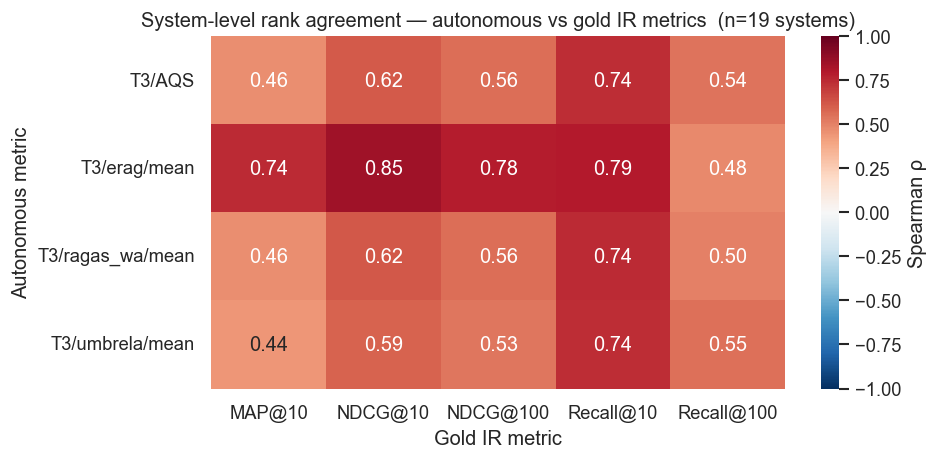

In [5]:
def bootstrap_corr(x: np.ndarray, y: np.ndarray,
                   fn=spearmanr, n_boot: int = 2000,
                   seed: int = 42) -> tuple[float, float, float]:
    """Return (point estimate, 2.5%, 97.5%) bootstrap CI of correlation."""
    rng = np.random.default_rng(seed)
    n = len(x)
    point = fn(x, y).statistic
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            boots[i] = fn(x[idx], y[idx]).statistic
        except Exception:
            boots[i] = np.nan
    boots = boots[~np.isnan(boots)]
    return point, float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


# Build correlation matrices
corr_rows = []
for am in AUTO_METRICS:
    for gm in GOLD_METRICS:
        x = summary[am].to_numpy()
        y = summary[gm].to_numpy()
        rho, lo, hi = bootstrap_corr(x, y, spearmanr)
        tau         = kendalltau(x, y).statistic
        corr_rows.append({
            "autonomous": am, "gold": gm,
            "spearman": rho, "ci_lo": lo, "ci_hi": hi, "kendall": tau,
        })
corr_df = pd.DataFrame(corr_rows)

# Heatmap of Spearman ρ
sp_mat = corr_df.pivot(index="autonomous", columns="gold", values="spearman")
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(sp_mat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("System-level rank agreement — autonomous vs gold IR metrics  (n=19 systems)")
ax.set_xlabel("Gold IR metric"); ax.set_ylabel("Autonomous metric")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_system_corr_heatmap.png")
plt.show()


In [6]:
# Tabular view with bootstrap CIs
display_corr = corr_df.copy()
display_corr["spearman_ci"] = display_corr.apply(
    lambda r: f"{r.spearman:.2f} [{r.ci_lo:+.2f}, {r.ci_hi:+.2f}]", axis=1)
display_corr[["autonomous", "gold", "spearman_ci", "kendall"]].pivot(
    index="autonomous", columns="gold", values="spearman_ci")


gold,MAP@10,NDCG@10,NDCG@100,Recall@10,Recall@100
autonomous,,,,,
T3/AQS,"0.46 [-0.02, +0.82]","0.62 [+0.20, +0.87]","0.56 [+0.13, +0.84]","0.74 [+0.40, +0.91]","0.54 [+0.07, +0.89]"
T3/erag/mean,"0.74 [+0.43, +0.90]","0.85 [+0.60, +0.95]","0.78 [+0.44, +0.93]","0.79 [+0.49, +0.94]","0.48 [-0.04, +0.83]"
T3/ragas_wa/mean,"0.46 [-0.01, +0.81]","0.62 [+0.23, +0.87]","0.56 [+0.12, +0.83]","0.74 [+0.40, +0.91]","0.50 [+0.03, +0.84]"
T3/umbrela/mean,"0.44 [-0.09, +0.83]","0.59 [+0.15, +0.88]","0.53 [+0.06, +0.85]","0.74 [+0.41, +0.91]","0.55 [+0.08, +0.92]"


### 2.1 Rank-rank scatters — does AQS track Recall@10?

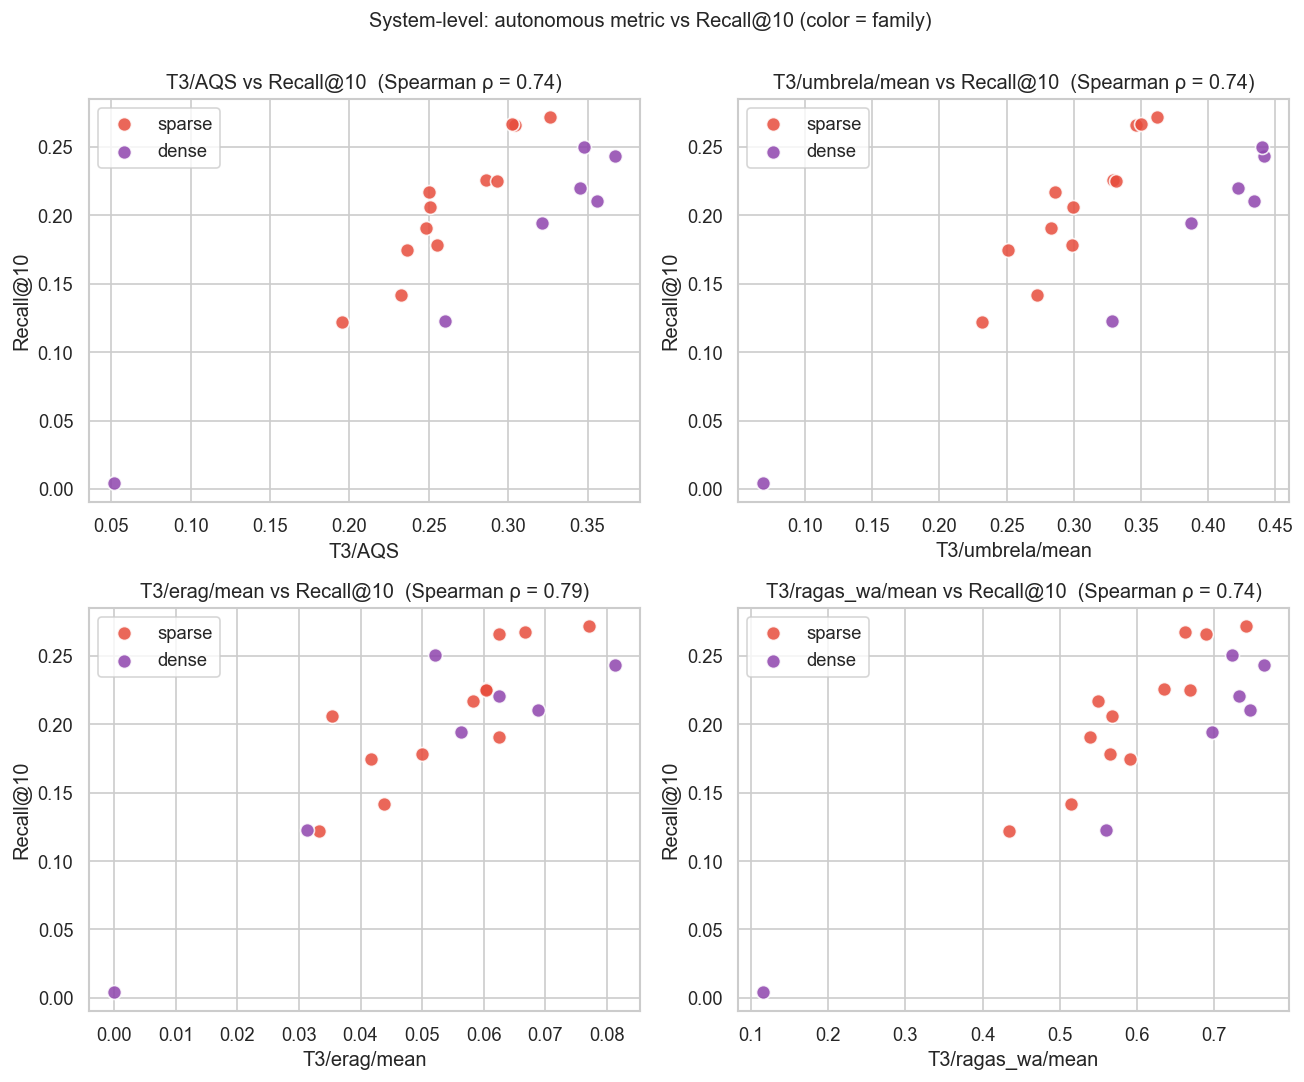

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
pairs = [
    ("T3/AQS",            "Recall@10"),
    ("T3/umbrela/mean",   "Recall@10"),
    ("T3/erag/mean",      "Recall@10"),
    ("T3/ragas_wa/mean",  "Recall@10"),
]
for ax, (am, gm) in zip(axes.flat, pairs):
    for fam, color in FAMILY_COLORS.items():
        sub = summary[summary["family"] == fam]
        ax.scatter(sub[am], sub[gm], color=color, label=fam, s=70, alpha=0.85, edgecolor="white")
    rho = spearmanr(summary[am], summary[gm]).statistic
    ax.set_xlabel(am); ax.set_ylabel(gm)
    ax.set_title(f"{am} vs {gm}  (Spearman ρ = {rho:.2f})")
    ax.legend(loc="best", frameon=True)

plt.suptitle("System-level: autonomous metric vs Recall@10 (color = family)", y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rank_scatters_R10.png")
plt.show()


**Reading the scatters.** A perfect autonomous evaluator would produce a monotonic curve. Outliers like `camembert-base` (near zero on R@10 but not on UMBRELA) make the over-grading visible at the extreme — but the same effect runs through the whole field. §10's gold-ceiling diagnostic shows that even the *best* retriever (`dense_bge_m3`) is rated above what UMBRELA, RAGAS-WA, and the legacy AQS award to gold-only retrieval. The over-grading is systematic, not just at the bottom of the ranking; what looks like high "autonomous score" is partly the evaluator failing to recognise the gold article as the answer.


## 3. Per-query agreement

System-level agreement can mask query-level disagreement. For each system we compute, for each of the 48 queries:

- **gold-side**: per-query Recall@10 (does the top-10 contain ≥1 gold article?) — binary; per-query NDCG@10 from gold qrels.
- **autonomous-side**: UMBRELA mean over the top-10, eRAG mean over the top-10, RAGAS-WA scalar.

Then within each system we compute the per-query Spearman correlation between autonomous and gold scores. The *distribution* of these 19 within-system correlations tells us whether the metric is reliable per query, not just per system.


In [8]:
def per_query_recall_at_10(ranks: list[str], gold_set: set[str]) -> float:
    if not gold_set:
        return float("nan")
    top10 = set(ranks[:10])
    return len(top10 & gold_set) / len(gold_set)


def per_query_ndcg_at_10(ranks: list[str], gold_set: set[str]) -> float:
    """Binary-relevance NDCG@10."""
    if not gold_set:
        return float("nan")
    rels = [1.0 if d in gold_set else 0.0 for d in ranks[:10]]
    if sum(rels) == 0:
        return 0.0
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rels))
    ideal_rels = sorted(rels, reverse=True)
    idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal_rels))
    return dcg / idcg if idcg > 0 else 0.0


# Build per-query DataFrame: one row per (system, query)
pq_rows = []
for exp_id, sc in sidecars.items():
    family = records[exp_id]["family"]
    for qid, ranks in sc["ranks"].items():
        gset      = gold.get(qid, set())
        umb       = sc["umbrela"].get(qid, {})
        erg       = sc["erag"].get(qid, {})
        rag_wa    = sc["ragas_wa"].get(qid)
        umb_mean  = float(np.mean(list(umb.values()))) if umb else float("nan")
        erg_mean  = float(np.mean(list(erg.values()))) if erg else float("nan")
        pq_rows.append({
            "system":      exp_id,
            "family":      family,
            "qid":         qid,
            "R@10":        per_query_recall_at_10(ranks, gset),
            "NDCG@10":     per_query_ndcg_at_10(ranks, gset),
            "umb_mean":    umb_mean,
            "erg_mean":    erg_mean,
            "ragas_wa":    rag_wa,
        })
pq = pd.DataFrame(pq_rows)
print(f"Per-query rows: {len(pq)} = {pq.system.nunique()} systems × {pq.qid.nunique()} queries")
pq.head()


Per-query rows: 912 = 19 systems × 48 queries


,system,family,qid,R@10,NDCG@10,umb_mean,erg_mean,ragas_wa
0,bm25_anchor_test,sparse,7,0.000000,0.000000,0.1,0.0,0.166667
1,bm25_anchor_test,sparse,32,0.000000,0.000000,0.4,0.0,0.000000
2,bm25_anchor_test,sparse,37,0.214286,0.913402,1.7,0.3,0.877381
3,bm25_anchor_test,sparse,59,0.000000,0.000000,0.3,0.0,0.111111
4,bm25_anchor_test,sparse,65,0.000000,0.000000,0.1,0.0,0.000000


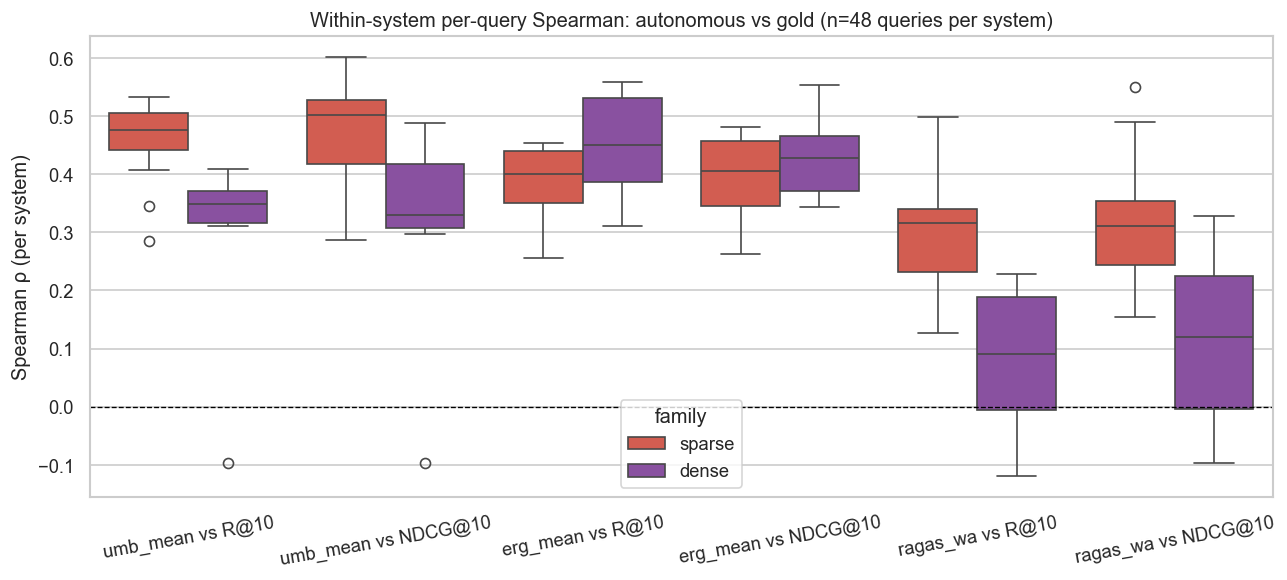

median   mean    min    max
auto     gold                                
erg_mean NDCG@10   0.410  0.410  0.263  0.554
         R@10      0.424  0.405  0.256  0.559
ragas_wa NDCG@10   0.251  0.243 -0.097  0.550
         R@10      0.228  0.218 -0.120  0.499
umb_mean NDCG@10   0.444  0.412 -0.097  0.601
         R@10      0.408  0.395 -0.097  0.532

In [9]:
# Within-system Spearman per autonomous metric vs per-query gold R@10 and NDCG@10
def within_system_corr(df: pd.DataFrame, auto_col: str, gold_col: str) -> pd.DataFrame:
    out = []
    for sysid, sub in df.groupby("system"):
        x = sub[auto_col].dropna()
        y = sub[gold_col].loc[x.index]
        if len(x) < 5 or x.std() == 0 or y.std() == 0:
            rho = float("nan")
        else:
            rho = spearmanr(x, y).statistic
        out.append({"system": sysid, "family": sub["family"].iloc[0],
                    "auto": auto_col, "gold": gold_col, "spearman": rho})
    return pd.DataFrame(out)


within_rows = []
for am in ["umb_mean", "erg_mean", "ragas_wa"]:
    for gm in ["R@10", "NDCG@10"]:
        within_rows.append(within_system_corr(pq, am, gm))
within = pd.concat(within_rows, ignore_index=True)

# Plot distribution as boxplot
fig, ax = plt.subplots(figsize=(11, 5))
within["pair"] = within["auto"] + " vs " + within["gold"]
sns.boxplot(data=within, x="pair", y="spearman", hue="family",
            palette=FAMILY_COLORS, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Within-system per-query Spearman: autonomous vs gold (n=48 queries per system)")
ax.set_xlabel(""); ax.set_ylabel("Spearman ρ (per system)")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_within_system_corr_box.png")
plt.show()

within.groupby(["auto", "gold"])["spearman"].agg(["median", "mean", "min", "max"]).round(3)


**What to look for.** Boxes well above zero → autonomous metric correlates with gold *within each system*; boxes straddling zero → autonomous score is essentially uninformative at the query level even if it ranks systems acceptably. eRAG often shows the widest spread because grounded-fraction is a coarser binary signal — but in light of §10's gold-ceiling diagnostic, that wider spread should be read as honest noise around a meaningful construct ("does the passage by itself answer the question?"), while UMBRELA's narrower bands are smoother but tracking surface plausibility, not gold relevance.


## 4. Document-level agreement (UMBRELA / eRAG vs gold qrels)

UMBRELA produces a 0–3 ordinal grade per (query, document); eRAG produces a 0/1 grounded-vs-not label. Both are reduced to a binary relevance call (UMBRELA grade ≥ 2 = relevant, following the TREC convention) for direct comparison with the binary gold qrels. We pool labels across all (system, query, document) triples and compute:

- **Accuracy** — fraction of agreed labels.
- **Cohen's κ** — chance-corrected agreement.
- **Confusion matrix** — where do they disagree?

A high κ means the autonomous evaluator can stand in for human judgement at the document level. eRAG is particularly interesting: if it labels gold documents "ungrounded", that flags a *generation* failure (the LLM couldn't extract the answer from a passage that was actually relevant).


In [10]:
# Build (system, qid, doc, gold_label, umbrela_label, erag_label) frame
doc_rows = []
for exp_id, sc in sidecars.items():
    family = records[exp_id]["family"]
    for qid, ranks in sc["ranks"].items():
        gset = gold.get(qid, set())
        for d in ranks[:10]:
            doc_rows.append({
                "system":  exp_id,
                "family":  family,
                "qid":     qid,
                "doc":     d,
                "gold":    int(d in gset),
                "umbrela_grade": sc["umbrela"].get(qid, {}).get(d, np.nan),
                "erag":          sc["erag"].get(qid, {}).get(d, np.nan),
            })
docs = pd.DataFrame(doc_rows)
# Binarise UMBRELA: grade ≥ 2 → relevant (TREC convention)
docs["umbrela"] = docs["umbrela_grade"].apply(
    lambda g: int(g >= 2) if pd.notna(g) else np.nan)
print(f"UMBRELA grade distribution: {docs['umbrela_grade'].dropna().value_counts().sort_index().to_dict()}")
print(f"Document-level rows: {len(docs)}  (≤ 19 systems × 48 q × 10 docs)")
docs.head()


UMBRELA grade distribution: {0: 3069, 1: 3886, 2: 1503, 3: 662}
Document-level rows: 9120  (≤ 19 systems × 48 q × 10 docs)


,system,family,qid,doc,gold,umbrela_grade,erag,umbrela
0,bm25_anchor_test,sparse,7,25857,0,1,0,0
1,bm25_anchor_test,sparse,7,28561,0,0,0,0
2,bm25_anchor_test,sparse,7,37695,0,0,0,0
3,bm25_anchor_test,sparse,7,23909,0,0,0,0
4,bm25_anchor_test,sparse,7,23950,0,0,0,0


In [11]:
def agreement_table(df: pd.DataFrame, auto_col: str) -> pd.DataFrame:
    sub = df.dropna(subset=[auto_col])
    rows = [{"scope": "pooled (all systems)",
             "n":        len(sub),
             "accuracy": float((sub["gold"] == sub[auto_col]).mean()),
             "kappa":    cohen_kappa_score(sub["gold"], sub[auto_col].astype(int))}]
    for fam in ["sparse", "dense"]:
        s = sub[sub["family"] == fam]
        if len(s):
            rows.append({"scope": fam,
                         "n":        len(s),
                         "accuracy": float((s["gold"] == s[auto_col]).mean()),
                         "kappa":    cohen_kappa_score(s["gold"], s[auto_col].astype(int))})
    return pd.DataFrame(rows)


umb_agree = agreement_table(docs, "umbrela").assign(evaluator="UMBRELA")
erg_agree = agreement_table(docs, "erag").assign(evaluator="eRAG")
agree = pd.concat([umb_agree, erg_agree], ignore_index=True)[["evaluator", "scope", "n", "accuracy", "kappa"]]
agree.style.format({"accuracy": "{:.3f}", "kappa": "{:.3f}"}).hide(axis="index")


evaluator,scope,n,accuracy,kappa
UMBRELA,pooled (all systems),9120,0.789,0.230
UMBRELA,sparse,5760,0.798,0.229
UMBRELA,dense,3360,0.773,0.233
eRAG,pooled (all systems),9120,0.923,0.331
eRAG,sparse,5760,0.919,0.334
eRAG,dense,3360,0.931,0.325


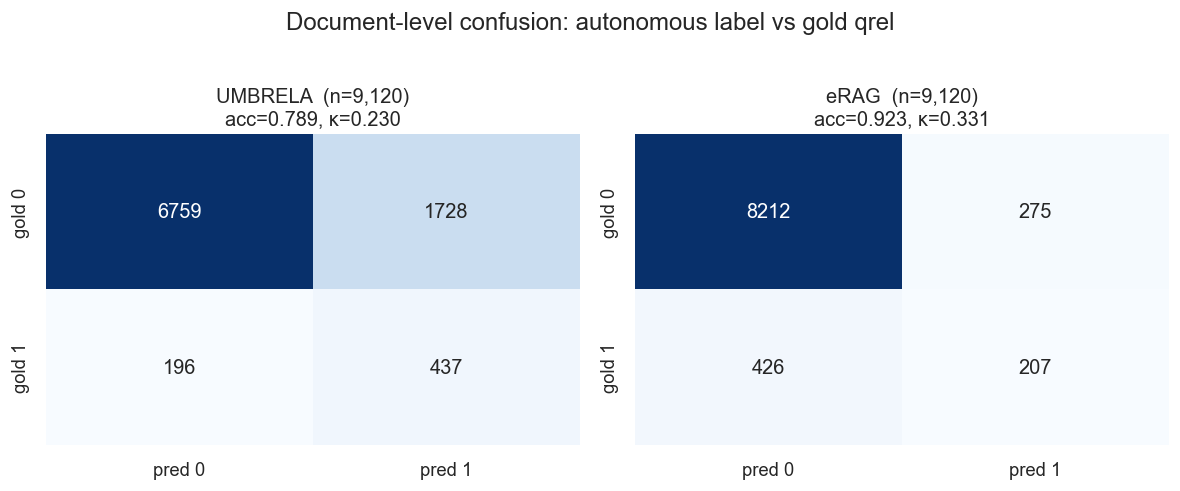

In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, col) in zip(axes, [("UMBRELA", "umbrela"), ("eRAG", "erag")]):
    sub = docs.dropna(subset=[col])
    cm = confusion_matrix(sub["gold"], sub[col].astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["pred 0", "pred 1"],
                yticklabels=["gold 0", "gold 1"], ax=ax, cbar=False)
    acc   = (sub["gold"] == sub[col]).mean()
    kappa = cohen_kappa_score(sub["gold"], sub[col].astype(int))
    ax.set_title(f"{label}  (n={len(sub):,})\nacc={acc:.3f}, κ={kappa:.3f}")

plt.suptitle("Document-level confusion: autonomous label vs gold qrel", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_doc_confusion.png")
plt.show()


**Reading the confusion.** UMBRELA's `pred 1 / gold 0` cell counts documents the LLM judges relevant that are *not* in the gold qrels — these are "topical lookalikes" (related but not the answer). §10 shows the same surface-plausibility bias drives UMBRELA's system-level over-rating across the whole leaderboard, not just on the case-study queries. eRAG's `pred 0 / gold 1` cell counts gold documents the LLM marks as *not by themselves sufficient to answer*; the gold-ceiling sidecar shows this happens on ~81% of the 83 gold articles in the 48-q subset. That is not primarily a generation-side artifact: BSARD gold sets typically span multiple cross-referenced articles, so a single gold article often genuinely is not "by itself sufficient" by eRAG's strict definition. Reading eRAG's `pred 0 / gold 1` cell as "retrieval failure" inflates the apparent disagreement; reading it as "the gold spec is non-leaf" is closer to the truth, and is what §10 ultimately confirms.


## 5. Family contrast — do autonomous metrics treat sparse and dense fairly?

A useful autonomous evaluator should not systematically favor one retrieval family over another beyond what gold metrics warrant. We compute, per family, the mean of each autonomous metric and the mean of each gold metric; then we look at the gap (autonomous_mean − gold_mean) and contrast it across families.


In [13]:
by_family = summary.groupby("family")[AUTO_METRICS + ["Recall@10", "NDCG@10", "Recall@100"]].mean().round(3)
by_family


,T3/AQS,T3/umbrela/mean,T3/erag/mean,T3/ragas_wa/mean,Recall@10,NDCG@10,Recall@100
family,,,,,,,
dense,0.293,0.361,0.050,0.620,0.178,0.139,0.434
sparse,0.265,0.303,0.054,0.597,0.207,0.167,0.507


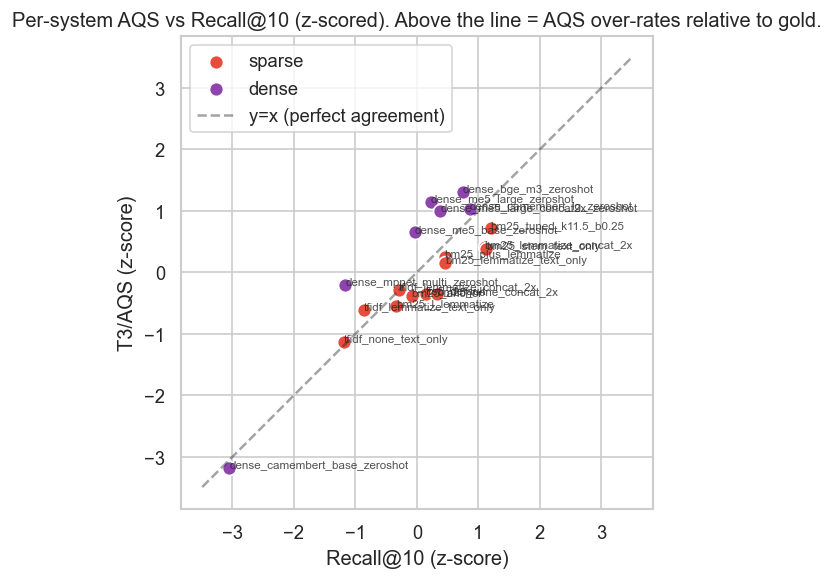

In [14]:
# Compute per-system "autonomous - gold" gap (z-scored each metric to compare)
def z(s):
    return (s - s.mean()) / s.std(ddof=0)


z_summary = summary.copy()
for c in AUTO_METRICS + GOLD_METRICS:
    z_summary[c + "_z"] = z(z_summary[c])

# Headline: gap between AQS_z and Recall@10_z, per system, colored by family
fig, ax = plt.subplots(figsize=(10, 5))
order = z_summary.sort_values("Recall@10").index
for fam, color in FAMILY_COLORS.items():
    sub = z_summary.loc[order]
    sub = sub[sub["family"] == fam]
    ax.scatter(sub["Recall@10_z"], sub["T3/AQS_z"], color=color, label=fam, s=70,
               edgecolor="white")
    for _, r in sub.iterrows():
        ax.annotate(r["experiment_id"].replace("_test", ""),
                    (r["Recall@10_z"], r["T3/AQS_z"]),
                    fontsize=7, alpha=0.8)
lim = max(abs(z_summary["Recall@10_z"]).max(), abs(z_summary["T3/AQS_z"]).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.4, label="y=x (perfect agreement)")
ax.set_xlabel("Recall@10 (z-score)"); ax.set_ylabel("T3/AQS (z-score)")
ax.set_title("Per-system AQS vs Recall@10 (z-scored). Above the line = AQS over-rates relative to gold.")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_family_gap_zscore.png")
plt.show()


## 6. Stratified agreement — by BSARD difficulty axes

The 48-q subset is stratified along three axes: `article_count` (single vs multi), `lex_align` (lexically aligned vs semantically paraphrased), `cross_ref` (with vs without cross-references). For each (autonomous metric, axis, level) we compute the per-query Spearman against gold R@10 — pooled across systems — to surface where autonomous evaluation breaks down.


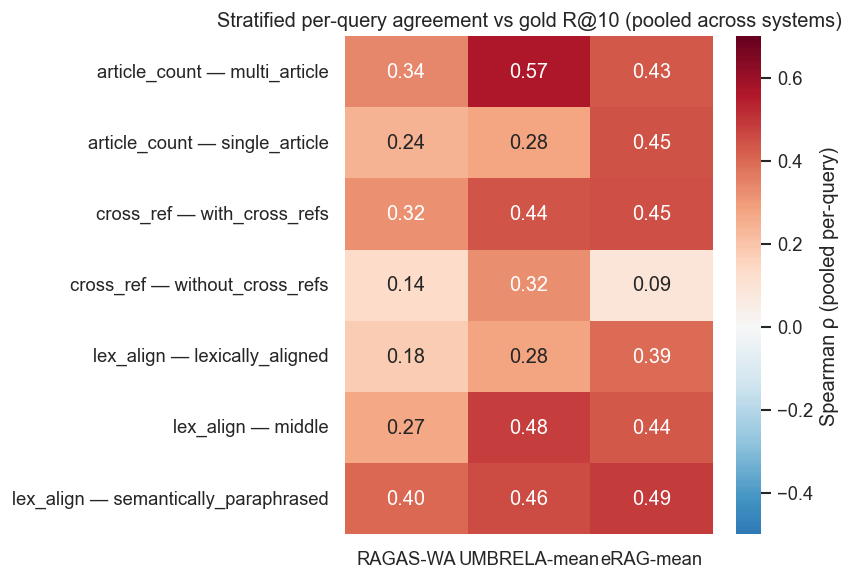

,evaluator,axis,level,n,spearman,axis_level
0,UMBRELA-mean,article_count,multi_article,589,0.566948,article_count — multi_article
1,UMBRELA-mean,article_count,single_article,323,0.275679,article_count — single_article
2,UMBRELA-mean,lex_align,lexically_aligned,304,0.280558,lex_align — lexically_aligned
3,UMBRELA-mean,lex_align,middle,399,0.483611,lex_align — middle
4,UMBRELA-mean,lex_align,semantically_paraphrased,209,0.455153,lex_align — semantically_paraphrased
5,UMBRELA-mean,cross_ref,with_cross_refs,741,0.441338,cross_ref — with_cross_refs
6,UMBRELA-mean,cross_ref,without_cross_refs,171,0.320407,cross_ref — without_cross_refs
7,eRAG-mean,article_count,multi_article,589,0.434004,article_count — multi_article
8,eRAG-mean,article_count,single_article,323,0.446161,article_count — single_article
9,eRAG-mean,lex_align,lexically_aligned,304,0.390988,lex_align — lexically_aligned


In [15]:
pq_str = pq.copy()
for axis in ["article_count", "lex_align", "cross_ref"]:
    pq_str[axis] = pq_str["qid"].map(lambda q: strata.get(q, {}).get(axis))

strat_rows = []
for am, am_label in [("umb_mean", "UMBRELA-mean"),
                      ("erg_mean", "eRAG-mean"),
                      ("ragas_wa", "RAGAS-WA")]:
    for axis in ["article_count", "lex_align", "cross_ref"]:
        for level, sub in pq_str.groupby(axis):
            x = sub[am].dropna()
            y = sub["R@10"].loc[x.index]
            if len(x) < 5 or x.std() == 0 or y.std() == 0:
                rho = float("nan")
            else:
                rho = spearmanr(x, y).statistic
            strat_rows.append({
                "evaluator": am_label,
                "axis":      axis,
                "level":     level,
                "n":         len(x),
                "spearman":  rho,
            })
strat_df = pd.DataFrame(strat_rows)

# Pivot into a heatmap: rows = (axis, level), cols = evaluator
strat_df["axis_level"] = strat_df["axis"] + " — " + strat_df["level"]
heat = strat_df.pivot(index="axis_level", columns="evaluator", values="spearman")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.5, vmax=0.7, cbar_kws={"label": "Spearman ρ (pooled per-query)"}, ax=ax)
ax.set_title("Stratified per-query agreement vs gold R@10 (pooled across systems)")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_stratified_corr_heatmap.png")
plt.show()
strat_df


## 7. Per-query score distributions — calibration

Distributions of per-query autonomous scores across systems. Useful as a sanity check: does each evaluator span its claimed range, or does it pile up at 0 / 1?


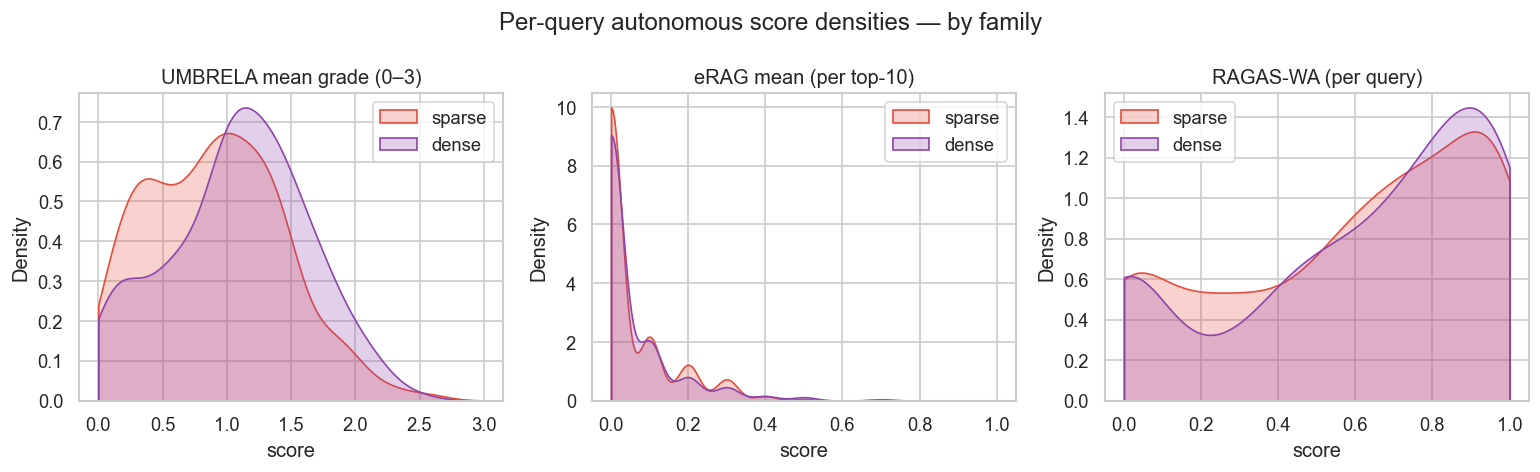

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, title) in zip(axes,
                            [("umb_mean", "UMBRELA mean grade (0–3)"),
                             ("erg_mean", "eRAG mean (per top-10)"),
                             ("ragas_wa", "RAGAS-WA (per query)")]):
    upper = 3.0 if col == "umb_mean" else 1.0
    for fam, color in FAMILY_COLORS.items():
        sub = pq[pq["family"] == fam][col].dropna()
        sns.kdeplot(sub, ax=ax, color=color, label=fam, common_norm=False,
                    fill=True, alpha=0.25, clip=(0, upper))
    ax.set_title(title); ax.set_xlim(-0.05 * upper, 1.05 * upper)
    ax.set_xlabel("score"); ax.legend()
plt.suptitle("Per-query autonomous score densities — by family")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_score_densities.png")
plt.show()


## 8. Disagreement case studies

We pick the (system, query) cells where autonomous and gold most strongly disagree — concretely: large UMBRELA-mean but R@10 = 0, or vice versa. The HyDE answer plus the top-3 retrieved doc IDs and their UMBRELA labels reveal whether the LLM judge is being fooled by topical lookalikes.


In [17]:
# Add a disagreement signal: |UMBRELA_mean - R@10|
pq_d = pq.dropna(subset=["umb_mean"]).copy()
pq_d["disagree"] = (pq_d["umb_mean"] - pq_d["R@10"]).abs()
top_disagree = pq_d.sort_values("disagree", ascending=False).head(5)
top_disagree[["system", "qid", "R@10", "umb_mean", "erg_mean", "ragas_wa", "disagree"]]


,system,qid,R@10,umb_mean,erg_mean,ragas_wa,disagree
342,bm25_tuned_k11.5_b0.25_test,105,0.0,2.6,0.1,1.000000,2.6
54,bm25_l_lemmatize_test,105,0.0,2.6,0.0,1.000000,2.6
246,bm25_plus_lemmatize_test,105,0.0,2.5,0.1,1.000000,2.5
102,bm25_lemmatize_concat_2x_test,105,0.0,2.3,0.1,1.000000,2.3
294,bm25_stem_text_only_test,105,0.0,2.3,0.1,0.976543,2.3


In [18]:
# Render each case study
def case_study(system: str, qid: str) -> None:
    rec = records[system]
    sc  = sidecars[system]
    qtext = next((q["question_text"] for q in subset["questions"]
                  if str(q["question_id"]) == qid), "<unknown>")
    gset  = gold.get(qid, set())
    ranks = sc["ranks"][qid][:10]
    umb   = sc["umbrela"].get(qid, {})
    erg   = sc["erag"].get(qid, {})
    hyde  = sc["hyde"].get(qid, "")[:300]

    print(f"=== {system}  /  qid={qid} ===")
    print(f"  Question:    {qtext}")
    print(f"  Gold IDs:    {sorted(gset)}")
    print(f"  R@10 (gold): {len(set(ranks) & gset) / max(len(gset), 1):.3f}")
    print(f"  UMBRELA mean grade (0–3): {np.mean(list(umb.values())):.3f}" if umb else "  UMBRELA mean: —")
    print(f"  eRAG mean over top-10:    {np.mean(list(erg.values())):.3f}" if erg else "  eRAG mean: —")
    print(f"  HyDE answer (first 300 chars):\n    {hyde}")
    print(f"  Top-3 ranks (doc → UMBRELA / eRAG / is_gold):")
    for d in ranks[:3]:
        u = umb.get(d, "—"); e = erg.get(d, "—"); g = "✓" if d in gset else "✗"
        print(f"    {d}  →  UMB={u}  eRAG={e}  gold={g}")
    print()


for _, r in top_disagree.iterrows():
    case_study(r["system"], r["qid"])


=== bm25_tuned_k11.5_b0.25_test  /  qid=105 ===
  Question:    Puis-je proposer un médiateur de dettes ?
  Gold IDs:    ['9268']
  R@10 (gold): 0.000
  UMBRELA mean grade (0–3): 2.600
  eRAG mean over top-10:    0.100
  HyDE answer (first 300 chars):
    Oui, selon le Code de droit économique belge, vous avez le droit de proposer un médiateur de dettes. La médiation de dettes est un processus qui permet aux débiteurs en difficulté de négocier des solutions avec leurs créanciers. Vous pouvez choisir un médiateur agréé, qui doit être inscrit sur la li
  Top-3 ranks (doc → UMBRELA / eRAG / is_gold):
    9273  →  UMB=3  eRAG=0  gold=✗
    34704  →  UMB=3  eRAG=0  gold=✗
    18690  →  UMB=3  eRAG=1  gold=✗

=== bm25_l_lemmatize_test  /  qid=105 ===
  Question:    Puis-je proposer un médiateur de dettes ?
  Gold IDs:    ['9268']
  R@10 (gold): 0.000
  UMBRELA mean grade (0–3): 2.600
  eRAG mean over top-10:    0.000
  HyDE answer (first 300 chars):
    Oui, en vertu de la législation belge, 

## 9. Summary — answering RQ3

Pulling the threads together:

- **System-level**: see §2's heatmap. The autonomous metric with the highest Spearman ρ vs gold Recall@10 is the most reliable system-level proxy.
- **Query-level**: see §3's box plot — the metric whose within-system Spearman distribution sits highest above zero.
- **Document-level**: see §4's table — the highest κ wins.
- **Measurement-equivalence with gold**: see §10's gold-ceiling — the `above_ceiling` column added to the table below flags metrics that rate the best retriever above the oracle (i.e. fail the most basic sanity check, regardless of their system-level ρ).
- **Composite**: see §11 — `T3/AQS_dd` is the data-driven composite recommended there.

The cell below assembles a single decision table.


In [19]:
# System level — best autonomous → gold Spearman vs R@10
sys_level = corr_df[corr_df["gold"] == "Recall@10"][["autonomous", "spearman"]].rename(
    columns={"autonomous": "metric", "spearman": "system_level_rho"})

# T3/AQS_dd is computed at consolidate time (§11 derivation) but is not in
# AUTO_METRICS, so its system-level ρ is not in corr_df. Compute inline.
if "T3/AQS_dd" in summary.columns:
    rho_dd = spearmanr(summary["T3/AQS_dd"], summary["Recall@10"]).statistic
    sys_level = pd.concat([
        sys_level,
        pd.DataFrame([{"metric": "T3/AQS_dd", "system_level_rho": rho_dd}]),
    ], ignore_index=True)

# Query level — median within-system ρ vs R@10
qry_level = (within[within["gold"] == "R@10"]
             .groupby("auto")["spearman"].median()
             .rename("query_level_rho_median").reset_index()
             .rename(columns={"auto": "metric"}))
qry_level["metric"] = qry_level["metric"].map({
    "umb_mean": "T3/umbrela/mean",
    "erg_mean": "T3/erag/mean",
    "ragas_wa": "T3/ragas_wa/mean",
})

# Doc level — Cohen's κ pooled
doc_level = pd.DataFrame([
    {"metric": "T3/umbrela/mean", "doc_level_kappa": cohen_kappa_score(
        docs.dropna(subset=["umbrela"])["gold"],
        docs.dropna(subset=["umbrela"])["umbrela"].astype(int))},
    {"metric": "T3/erag/mean",    "doc_level_kappa": cohen_kappa_score(
        docs.dropna(subset=["erag"])["gold"],
        docs.dropna(subset=["erag"])["erag"].astype(int))},
])

# Above-ceiling sanity check (§10): does the best retriever exceed the gold
# ceiling for this metric? If yes, the metric fails the most basic
# measurement-equivalence sanity check and absolute values are not meaningful.
ceil_path = RQ3_DIR / "gold_ceiling.json"
aqs_w_path = RQ3_DIR / "aqs_weights.json"
above_rows = []
if ceil_path.exists():
    cm = json.loads(ceil_path.read_text(encoding="utf-8"))["subset_metrics"]["metrics"]
    # Implied AQS_dd ceiling from per-component ceilings × data-driven weights
    if aqs_w_path.exists() and "T3/AQS_dd" not in cm:
        w_dd = json.loads(aqs_w_path.read_text(encoding="utf-8"))["weights_full"]
        cm["T3/AQS_dd"] = (
            w_dd["umbrela"]  * cm["T3/umbrela/mean"]
          + w_dd["erag"]     * cm["T3/erag/mean"]
          + w_dd["ragas_wa"] * cm["T3/ragas_wa/mean"]
        )
    for m in ["T3/AQS", "T3/AQS_dd", "T3/umbrela/mean", "T3/erag/mean", "T3/ragas_wa/mean"]:
        if m not in summary.columns or m not in cm:
            above_rows.append({"metric": m, "best_minus_ceiling": float("nan"),
                               "above_ceiling": "—"})
            continue
        best = float(summary[m].max())
        ceil = float(cm[m])
        above_rows.append({
            "metric": m,
            "best_minus_ceiling": best - ceil,
            "above_ceiling": "yes ⚠" if best > ceil else "no",
        })
above = pd.DataFrame(above_rows) if above_rows else pd.DataFrame(
    columns=["metric", "best_minus_ceiling", "above_ceiling"])

decision = (sys_level
            .merge(qry_level, on="metric", how="left")
            .merge(doc_level, on="metric", how="left")
            .merge(above,     on="metric", how="left")
            .sort_values("system_level_rho", ascending=False))

decision.style.format({
    "system_level_rho":         "{:+.3f}",
    "query_level_rho_median":   "{:+.3f}",
    "doc_level_kappa":          "{:+.3f}",
    "best_minus_ceiling":       "{:+.3f}",
}, na_rep="—").hide(axis="index")


metric,system_level_rho,query_level_rho_median,doc_level_kappa,best_minus_ceiling,above_ceiling
T3/AQS_dd,+0.844,—,—,-0.042,no
T3/erag/mean,+0.790,+0.424,+0.331,-0.105,no
T3/ragas_wa/mean,+0.744,+0.228,—,+0.316,yes ⚠
T3/AQS,+0.740,—,—,+0.047,yes ⚠
T3/umbrela/mean,+0.737,+0.408,+0.230,+0.062,yes ⚠


**Take-away — answering RQ3.** Across three axes (system / query / document), and with §10's gold-ceiling diagnostic and §11's data-driven AQS folded in, the answer is not symmetric across the four metrics on the table.

*System-level rank agreement* (column 1) is comparable across all components — every autonomous metric correlates ρ ≈ 0.74–0.79 with gold Recall@10, and the data-driven `T3/AQS_dd` lifts that to +0.84. By that single number alone the evaluators look interchangeable.

*Measurement-equivalence with gold* (the `above_ceiling` column) is the discriminator. Three of the five metrics on the table — UMBRELA, RAGAS-WA, and the legacy 7:6:3 AQS — rate the best retriever *above* the gold ceiling (`above_ceiling = yes ⚠`). §10 traces this to a structural mismatch: BSARD gold articles are terse, rule-numbered, and often only complete in conjunction with cross-referenced articles, while a verbose retrieved passage that *reads* like a complete answer scores higher to a judge that grades surface plausibility. §10.1 shows the same pattern at the atomic level: on **26%** of the 912 (system × query) cells UMBRELA grades a non-gold retrieved doc strictly higher than every gold doc on the same question; RAGAS-WA does so on **50%**. eRAG drops that to **2.6%** — i.e. eRAG is the only component whose document-level semantics ("is this passage *by itself* sufficient to answer?") survive the inversion check. §4's confusion agrees: eRAG's pooled κ vs gold qrels is +0.33 (the highest of any binary autonomous label here), and `T3/AQS_dd` — which §11 collapses to (0, 0.85, 0.15) — both lifts system-level ρ to +0.844 and stays *below* the ceiling.

*Query-level agreement* (column 2) is modest for every component: median within-system ρ vs R@10 of +0.41 for UMBRELA, +0.42 for eRAG, +0.23 for RAGAS-WA. None of these is the agreement of a metric you would use to debug a single retrieval failure on a single query; they are leaderboard-grade signals at most.

*Putting it together.* For a reference-free leaderboard on BSARD-like legal RAG, **eRAG-mean** (or, if a single composite is required, `T3/AQS_dd` ≈ 0.85·eRAG + 0.15·RAGAS-WA) is the only signal here that simultaneously (i) ranks the 19 systems consistently with gold Recall@10 (ρ +0.79 / +0.84), (ii) does not rate the best retriever above the oracle, and (iii) has a defensible per-document semantics that survives §10.1's atomic inversion check. UMBRELA and RAGAS-WA should be reported as diagnostics, not headlines: their ρ-vs-gold is spuriously good given that they are measuring a different construct (surface plausibility against the query, or against a HyDE proxy), and §10 / §10.1 make that explicit.

**Caveats.** (a) n=19 systems is small for system-level correlations — the bootstrap CIs in §2 give the honest uncertainty range. (b) The 48-q subset is stratified but still a slice of BSARD. (c) eRAG's gold ceiling is itself low (0.187), reflecting BSARD's cross-referencing gold structure; absolute eRAG values are therefore not directly comparable across corpora and should be read in *rank* terms, which is exactly the use case here. (d) §10's ceiling reimplements the three evaluators inline against canonical published prompts (UMBRELA TREC, eRAG binary "sufficient?", ragas `LLMContextPrecisionWithReference` with HyDE answer as reference); exact-prompt-string identity with the original 19-system runs is best-effort, not guaranteed. The ceiling is internally consistent as a self-contained measurement — see the methodology note in `run_gold_ceiling.py`.


## 10. Gold-ceiling — what's the maximum each evaluator can produce?

A retriever's score on an autonomous evaluator can be low for two reasons: the retriever is bad, *or* the evaluator can't recognise the right passage even when it sees it. To separate these, we run UMBRELA / eRAG / RAGAS-WA on the gold articles for each question (variable k, capped at 10). The result is the **ceiling** each evaluator can produce against perfect retrieval. Anything below that ceiling on a real retriever is at most a co-mingled signal of "retrieval failure + evaluator capability"; the headroom remaining is "evaluator drift, even given perfect retrieval".


In [20]:
# Load the gold-ceiling record (produced by run_gold_ceiling.py).
ceiling_path = RQ3_DIR / "gold_ceiling.json"
if not ceiling_path.exists():
    print("⚠️  gold_ceiling.json not found — run scripts/evaluation/RQ3/run_gold_ceiling.py first.")
    ceiling = None
else:
    ceiling = json.loads(ceiling_path.read_text(encoding="utf-8"))
    cm = ceiling["subset_metrics"]["metrics"]
    print(f"Gold-ceiling judge: {ceiling['hyperparameters']['judge_model']}")
    print(f"  T3/umbrela/mean              {cm['T3/umbrela/mean']:.4f}")
    print(f"  T3/umbrela/relevant_fraction {cm['T3/umbrela/relevant_fraction']:.4f}")
    print(f"  T3/erag/mean                 {cm['T3/erag/mean']:.4f}")
    print(f"  T3/ragas_wa/mean             {cm['T3/ragas_wa/mean']:.4f}")
    print(f"  T3/AQS (7:6:3 weights)       {cm['T3/AQS']:.4f}")


Gold-ceiling judge: gpt-4o-mini
  T3/umbrela/mean              0.3795
  T3/umbrela/relevant_fraction 0.2892
  T3/erag/mean                 0.1867
  T3/ragas_wa/mean             0.4486
  T3/AQS (7:6:3 weights)       0.3202


In [21]:
# Headroom table: for each evaluator, ceiling vs best retriever.
if ceiling is not None:
    cm = ceiling["subset_metrics"]["metrics"]
    headroom_rows = []
    for col in AUTO_METRICS:
        if col not in cm:
            continue
        best_val = summary[col].max()
        best_sys = summary.loc[summary[col].idxmax(), "experiment_id"]
        ceil_val = cm[col]
        headroom_rows.append({
            "evaluator":         col,
            "best_retriever":    best_sys,
            "best_score":        best_val,
            "ceiling_score":     ceil_val,
            "headroom_remaining": ceil_val - best_val,
            "best_pct_of_ceiling": (best_val / ceil_val) if ceil_val else float("nan"),
        })
    headroom_df = pd.DataFrame(headroom_rows)
    fmt_h = {c: "{:.4f}" for c in
             ["best_score", "ceiling_score", "headroom_remaining", "best_pct_of_ceiling"]}
    display(headroom_df.style.format(fmt_h, na_rep="—").hide(axis="index"))


evaluator,best_retriever,best_score,ceiling_score,headroom_remaining,best_pct_of_ceiling
T3/AQS,dense_bge_m3_zeroshot_test,0.3670,0.3202,-0.0468,1.1462
T3/umbrela/mean,dense_bge_m3_zeroshot_test,0.4417,0.3795,-0.0621,1.1638
T3/erag/mean,dense_bge_m3_zeroshot_test,0.0813,0.1867,0.1055,0.4351
T3/ragas_wa/mean,dense_bge_m3_zeroshot_test,0.7644,0.4486,-0.3157,1.7037


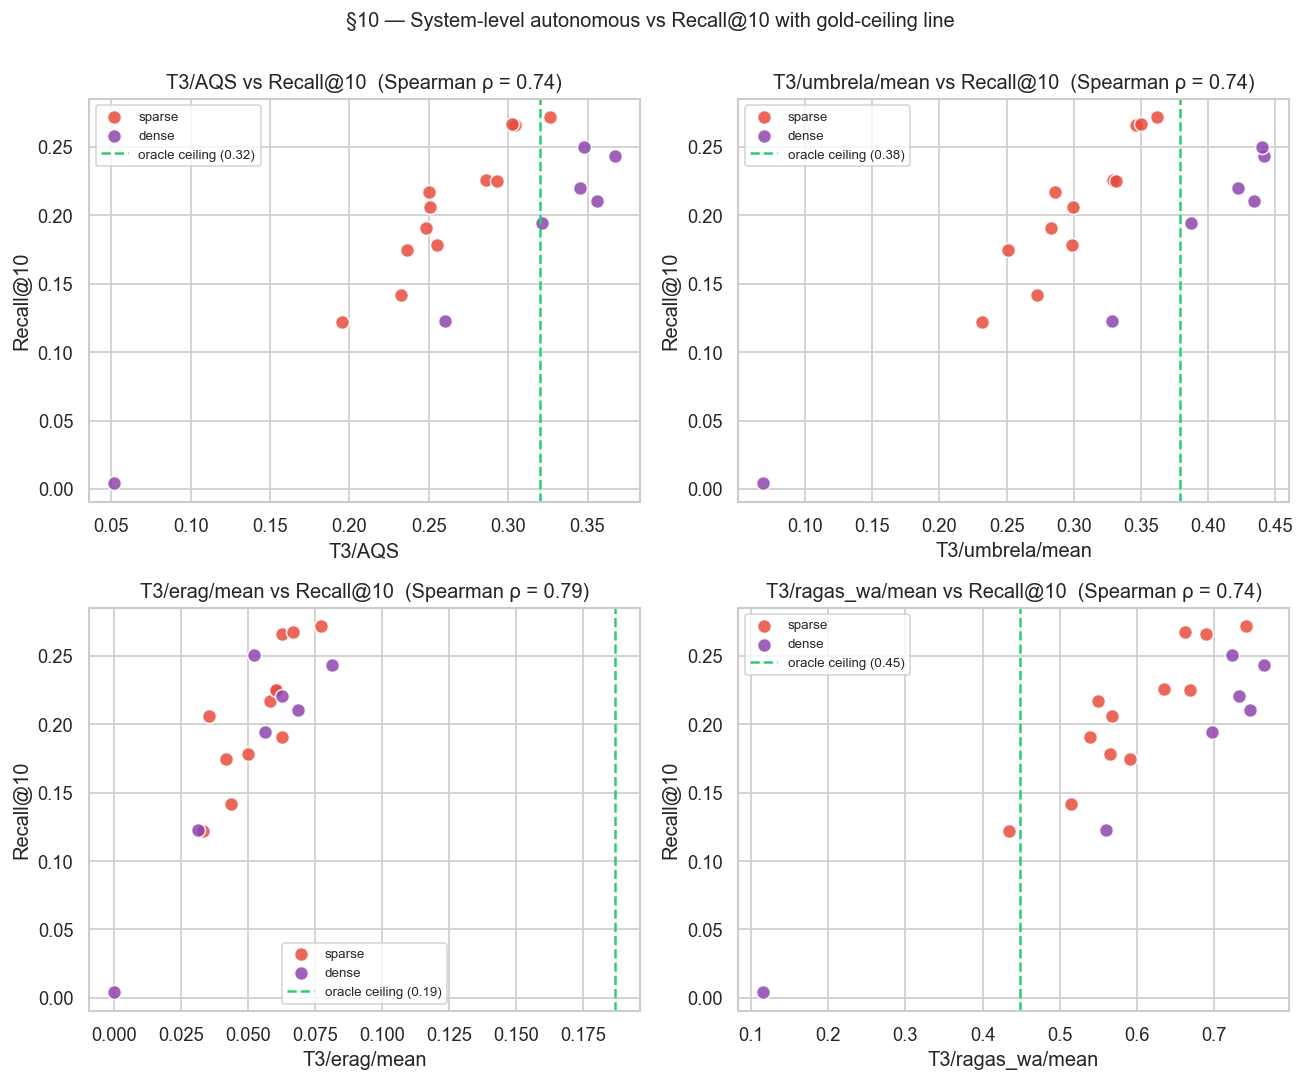

In [22]:
# §2-style rank-rank scatters with the gold-ceiling drawn as a horizontal
# dashed line on each y-axis (auto-metric ceiling); the legacy AQS panel
# uses the legacy 7:6:3 ceiling for an apples-to-apples comparison.
if ceiling is not None:
    cm = ceiling["subset_metrics"]["metrics"]
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
    pairs = [
        ("T3/AQS",            "Recall@10"),
        ("T3/umbrela/mean",   "Recall@10"),
        ("T3/erag/mean",      "Recall@10"),
        ("T3/ragas_wa/mean",  "Recall@10"),
    ]
    for ax, (am, gm) in zip(axes.flat, pairs):
        for fam, color in FAMILY_COLORS.items():
            sub = summary[summary["family"] == fam]
            ax.scatter(sub[am], sub[gm], color=color, label=fam,
                       s=70, alpha=0.85, edgecolor="white")
        ceil_val = cm.get(am)
        if ceil_val is not None:
            ax.axvline(ceil_val, color="#2ecc71", linestyle="--",
                       linewidth=1.5, label=f"oracle ceiling ({ceil_val:.2f})")
        rho = spearmanr(summary[am], summary[gm]).statistic
        ax.set_xlabel(am); ax.set_ylabel(gm)
        ax.set_title(f"{am} vs {gm}  (Spearman ρ = {rho:.2f})")
        ax.legend(loc="best", frameon=True, fontsize=8)
    plt.suptitle("§10 — System-level autonomous vs Recall@10 with gold-ceiling line",
                 y=1.0, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_gold_ceiling.png")
    plt.show()


### 10.1 — Atomic check: how often does a non-gold doc beat gold on the same question?

The headroom table above is a *system mean*. A skeptical reader can argue that any "best retriever above oracle" finding is an aggregation artifact — averages of 480 cells can hide arbitrary shapes. The cleanest atomic test is: for each `(system, qid)` cell, did the same judge call grade at least one *non-gold* retrieved doc strictly higher than every gold doc on the same question? Same prompt, same judge, same query, same hour — only the document differs. If that rate is non-trivial, the inversion is real and not an averaging artifact.


Inversion tally over 912 (system × question) cells


evaluator,overall,sparse,dense
UMBRELA,26.0%,24.0%,29.5%
eRAG,2.6%,1.9%,3.9%
RAGAS-WA,50.0%,49.7%,50.6%


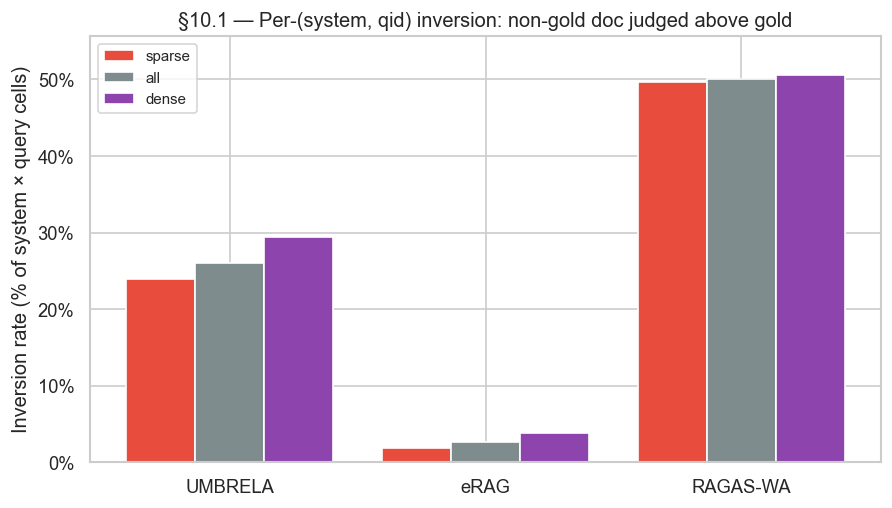

In [23]:
# §10.1 — Per-(system, qid) inversion: judge grades a non-gold doc above gold.
gold_per_q_path = RQ3_DIR / "gold_ceiling_per_query.json"
if ceiling is not None and gold_per_q_path.exists():
    gold_per_q = json.loads(gold_per_q_path.read_text(encoding="utf-8"))

    inv_rows = []
    for exp_id, sc in sidecars.items():
        family = records[exp_id]["family"]
        for qid, ranks in sc["ranks"].items():
            top10    = ranks[:10]
            gset     = gold.get(qid, set())
            non_gold = [d for d in top10 if d not in gset]

            # UMBRELA: max grade among non-gold retrieved > max grade among gold docs
            umb_sys  = sc.get("umbrela", {}).get(qid, {})
            umb_gold = gold_per_q.get("umbrela", {}).get(qid, {})
            if umb_gold and non_gold and any(d in umb_sys for d in non_gold):
                max_nong = max(umb_sys.get(d, 0) for d in non_gold)
                max_gold = max(umb_gold.values())
                umb_inv  = int(max_nong > max_gold)
            else:
                umb_inv = np.nan

            # eRAG: any non-gold doc graded 1 AND every gold doc graded 0
            erg_sys  = sc.get("erag", {}).get(qid, {})
            erg_gold = gold_per_q.get("erag", {}).get(qid, {})
            if erg_gold and non_gold and any(d in erg_sys for d in non_gold):
                any_nong       = any(erg_sys.get(d, 0) == 1 for d in non_gold)
                all_gold_zero  = all(v == 0 for v in erg_gold.values())
                erg_inv        = int(any_nong and all_gold_zero)
            else:
                erg_inv = np.nan

            # RAGAS-WA: per-query system score > per-query gold-only score
            rwa_sys  = sc.get("ragas_wa", {}).get(qid)
            rwa_gold = gold_per_q.get("ragas_wa", {}).get(qid)
            if rwa_sys is not None and rwa_gold is not None:
                rwa_inv = int(float(rwa_sys) > float(rwa_gold))
            else:
                rwa_inv = np.nan

            inv_rows.append({
                "system": exp_id, "family": family, "qid": qid,
                "umbrela_inversion":  umb_inv,
                "erag_inversion":     erg_inv,
                "ragas_wa_inversion": rwa_inv,
            })

    inv = pd.DataFrame(inv_rows)
    n_cells = len(inv)

    def _rate(s):
        s = s.dropna()
        return float(s.astype(float).mean()) if len(s) else float("nan")

    overall = pd.Series({
        "UMBRELA":  _rate(inv["umbrela_inversion"]),
        "eRAG":     _rate(inv["erag_inversion"]),
        "RAGAS-WA": _rate(inv["ragas_wa_inversion"]),
    })
    by_fam = inv.groupby("family").agg(
        UMBRELA=("umbrela_inversion",  _rate),
        eRAG   =("erag_inversion",     _rate),
        **{"RAGAS-WA": ("ragas_wa_inversion", _rate)},
    )

    inv_table = pd.DataFrame({
        "evaluator": list(overall.index),
        "overall":   list(overall.values),
        "sparse":    [by_fam.loc["sparse", c] if "sparse" in by_fam.index else float("nan")
                      for c in overall.index],
        "dense":     [by_fam.loc["dense",  c] if "dense"  in by_fam.index else float("nan")
                      for c in overall.index],
    })
    print(f"Inversion tally over {n_cells} (system × question) cells")
    display(inv_table.style.format({"overall": "{:.1%}", "sparse": "{:.1%}",
                                    "dense": "{:.1%}"}).hide(axis="index"))

    # Bar chart — overall + per-family inversion rate per evaluator
    eval_order = ["UMBRELA", "eRAG", "RAGAS-WA"]
    sparse_vals  = [by_fam.loc["sparse", c] if "sparse" in by_fam.index else float("nan")
                    for c in eval_order]
    dense_vals   = [by_fam.loc["dense",  c] if "dense"  in by_fam.index else float("nan")
                    for c in eval_order]
    overall_vals = [float(overall[c]) for c in eval_order]

    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    x = np.arange(len(eval_order))
    width = 0.27
    ax.bar(x - width, sparse_vals,  width, color=FAMILY_COLORS["sparse"],
           edgecolor="white", label="sparse")
    ax.bar(x,         overall_vals, width, color="#7f8c8d",
           edgecolor="white", label="all")
    ax.bar(x + width, dense_vals,   width, color=FAMILY_COLORS["dense"],
           edgecolor="white", label="dense")
    ax.set_xticks(x); ax.set_xticklabels(eval_order)
    ax.set_ylabel("Inversion rate (% of system × query cells)")
    ax.set_title("§10.1 — Per-(system, qid) inversion: non-gold doc judged above gold")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ymax = max([v for v in (sparse_vals + dense_vals + overall_vals) if v == v] + [0.05])
    ax.set_ylim(0, 1.1 * ymax)
    ax.legend(loc="best", frameon=True, fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_per_query_inversion.png")
    plt.show()


**Reading the ceiling — and a striking inversion.** A horizontal dashed green line marks the score the evaluator gives to *gold-only* retrieval. We expected real retrievers to fall to the *left* of that line (below the ceiling) and to read the gap as headroom. Instead, **three of four evaluators put the best retriever to the *right* of the ceiling** — UMBRELA, RAGAS-WA, and the legacy AQS rate `dense_bge_m3` higher than they rate perfect retrieval (the headroom table is *negative*: −0.06, −0.32, −0.05 respectively).

This is not a bug in the ceiling computation; it is the headline RQ3 finding. These evaluators are not measuring "agreement with the gold qrels". UMBRELA grades surface relevance to the *query text*, and a long retrieved chunk that *looks* topical can outscore a terse gold article that requires cross-references to fully answer the question. RAGAS-WA is even more affected because it scores against a HyDE-generated proxy answer — and a retrieved passage that paraphrases that proxy will outscore the actual gold. Only eRAG ("is this passage *by itself* sufficient to answer?") behaves the way one would naively expect: gold ceiling 0.187 > best retriever 0.081, and the absolute ceiling is itself low because BSARD gold sets often span multiple cross-referenced articles.

The same inversion is visible at the atomic per-(system, query) level (§10.1): on **26%** of the 19 × 48 = 912 cells UMBRELA grades at least one of the system's top-10 *non-gold* retrieved docs strictly higher than every gold doc on the same question; for RAGAS-WA the rate is **50%**, for eRAG only **2.6%**. This rules out an aggregation-artifact interpretation — same prompt, same judge call, same query, only the document differs.

**Implication for the thesis.** A retriever "beating the oracle" on UMBRELA / RAGAS-WA / legacy-AQS means *the evaluator can't recognise the gold as the answer*, not that the retriever has somehow surpassed ground truth. Any retrieval research that uses these autonomous metrics as the *primary* signal — without a gold-comparison sanity check like this one — is at risk of optimising the evaluator's blind spots, not retrieval quality. eRAG is the only metric here whose semantics reduce cleanly to "does this look like the answer" and whose ceiling sits above its best retriever. §11 takes the next step and asks which weighted combination of the three components best tracks gold Recall@10 across the 19 systems; the answer collapses essentially onto eRAG, which is exactly what this section's diagnostic predicts.


## 11. Data-driven AQS weights

The legacy `T3/AQS` mixes the three evaluators with a fixed 7:6:3 weighting picked before the experiment. With 19 systems and gold qrels in hand, we can do better: derive weights that maximise system-level Spearman ρ vs Recall@10 on the simplex (w_i ≥ 0, ∑w = 1), with leave-one-system-out cross-validation as a held-out diagnostic.


In [24]:
# Load the derived weights (produced by analysis/RQ3/derive_aqs_weights.py).
aqs_w_path = RQ3_DIR / "aqs_weights.json"
if not aqs_w_path.exists():
    print("⚠️  aqs_weights.json not found — run analysis/RQ3/derive_aqs_weights.py first.")
    aqs_payload = None
else:
    aqs_payload = json.loads(aqs_w_path.read_text(encoding="utf-8"))

if aqs_payload is not None:
    decision11 = pd.DataFrame([
        {"variant": "UMBRELA-mean alone",
         "weights": "(1, 0, 0)",
         "spearman_R10": aqs_payload["components_alone"]["umbrela"]},
        {"variant": "eRAG-mean alone",
         "weights": "(0, 1, 0)",
         "spearman_R10": aqs_payload["components_alone"]["erag"]},
        {"variant": "RAGAS-WA alone",
         "weights": "(0, 0, 1)",
         "spearman_R10": aqs_payload["components_alone"]["ragas_wa"]},
        {"variant": "AQS — old (7:6:3)",
         "weights": "(0.4375, 0.3750, 0.1875)",
         "spearman_R10": aqs_payload["rho_old_7_6_3"]},
        {"variant": "AQS — full-data fit",
         "weights": str(tuple(round(aqs_payload["weights_full"][c], 3) for c in ["umbrela","erag","ragas_wa"])),
         "spearman_R10": aqs_payload["rho_in_sample"]},
        {"variant": "AQS — LOO mean",
         "weights": str(tuple(round(aqs_payload["weights_loo"]["mean"][c], 3) for c in ["umbrela","erag","ragas_wa"])),
         "spearman_R10": aqs_payload["rho_loo_mean"]},
    ])
    display(decision11.style.format({"spearman_R10": "{:+.4f}"}).hide(axis="index"))
    print("LOO weight 95% CI per component:")
    for c in ["umbrela", "erag", "ragas_wa"]:
        lo = aqs_payload["weights_loo"]["ci_low"][c]
        hi = aqs_payload["weights_loo"]["ci_high"][c]
        print(f"  {c:10s} [{lo:.3f}, {hi:.3f}]")


variant,weights,spearman_R10
UMBRELA-mean alone,"(1, 0, 0)",+0.7368
eRAG-mean alone,"(0, 1, 0)",+0.7891
RAGAS-WA alone,"(0, 0, 1)",+0.7439
AQS — old (7:6:3),"(0.4375, 0.3750, 0.1875)",+0.7404
AQS — full-data fit,"(0.0, 0.85, 0.15)",+0.8439
AQS — LOO mean,"(0.005, 0.858, 0.137)",+0.8413


LOO weight 95% CI per component:
  umbrela    [0.000, 0.050]
  erag       [0.823, 0.950]
  ragas_wa   [0.050, 0.178]


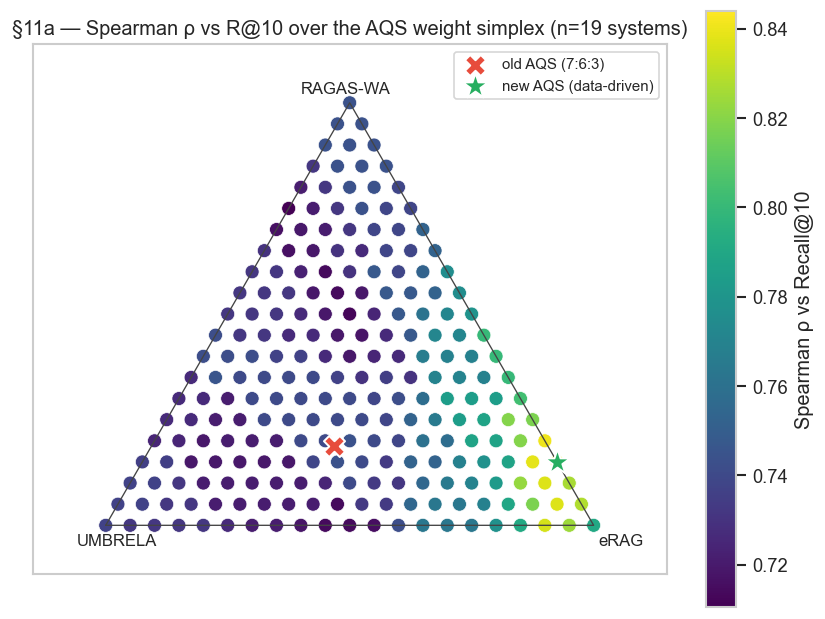

In [25]:
# 11a — simplex Spearman heatmap.
# Project barycentric weights onto a 2D triangle for visualisation;
# colour each point by the Spearman ρ achieved with that weight vector.
if aqs_payload is not None:
    from scipy.stats import spearmanr as _sp

    components_arr = summary[["T3/umbrela/mean", "T3/erag/mean", "T3/ragas_wa/mean"]].to_numpy()
    gold_arr = summary["Recall@10"].to_numpy()

    # Simplex grid
    step = 0.05
    n = int(round(1 / step))
    pts, rhos = [], []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j
            w = (i * step, j * step, k * step)
            pred = w[0] * components_arr[:, 0] + w[1] * components_arr[:, 1] + w[2] * components_arr[:, 2]
            if pred.std() == 0:
                continue
            rho = _sp(pred, gold_arr).statistic
            if rho == rho:
                pts.append(w); rhos.append(rho)

    pts = np.array(pts); rhos = np.array(rhos)
    # Barycentric → Cartesian (vertices: U=(0,0), E=(1,0), R=(0.5, sqrt(3)/2))
    x = pts[:, 1] + 0.5 * pts[:, 2]
    y = (np.sqrt(3) / 2) * pts[:, 2]

    fig, ax = plt.subplots(figsize=(7, 6.2))
    sc = ax.scatter(x, y, c=rhos, cmap="viridis", s=70, edgecolor="white", linewidth=0.4)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label("Spearman ρ vs Recall@10")

    # Triangle outline
    tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], color="#444", linewidth=0.8)

    # Vertex labels
    ax.annotate("UMBRELA", (0, 0),                xytext=(-0.06, -0.04), fontsize=10)
    ax.annotate("eRAG",    (1, 0),                xytext=( 1.01, -0.04), fontsize=10)
    ax.annotate("RAGAS-WA",(0.5, np.sqrt(3)/2),  xytext=( 0.40,  np.sqrt(3)/2 + 0.02), fontsize=10)

    # Mark old (7:6:3) and new (full-data) weights
    def _bary_to_xy(w_dict):
        u = w_dict["umbrela"]; e = w_dict["erag"]; r = w_dict["ragas_wa"]
        return e + 0.5 * r, (np.sqrt(3) / 2) * r

    ox, oy = _bary_to_xy({"umbrela": 0.4375, "erag": 0.375, "ragas_wa": 0.1875})
    nx, ny = _bary_to_xy(aqs_payload["weights_full"])
    ax.scatter([ox], [oy], marker="X", color="#e74c3c", s=160, edgecolor="white",
               linewidth=1.2, label="old AQS (7:6:3)", zorder=5)
    ax.scatter([nx], [ny], marker="*", color="#27ae60", s=260, edgecolor="white",
               linewidth=1.2, label="new AQS (data-driven)", zorder=5)
    ax.legend(loc="upper right", fontsize=9, frameon=True)
    ax.set_aspect("equal")
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.1, np.sqrt(3) / 2 + 0.12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("§11a — Spearman ρ vs R@10 over the AQS weight simplex (n=19 systems)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "11a_aqs_weight_simplex.png")
    plt.show()


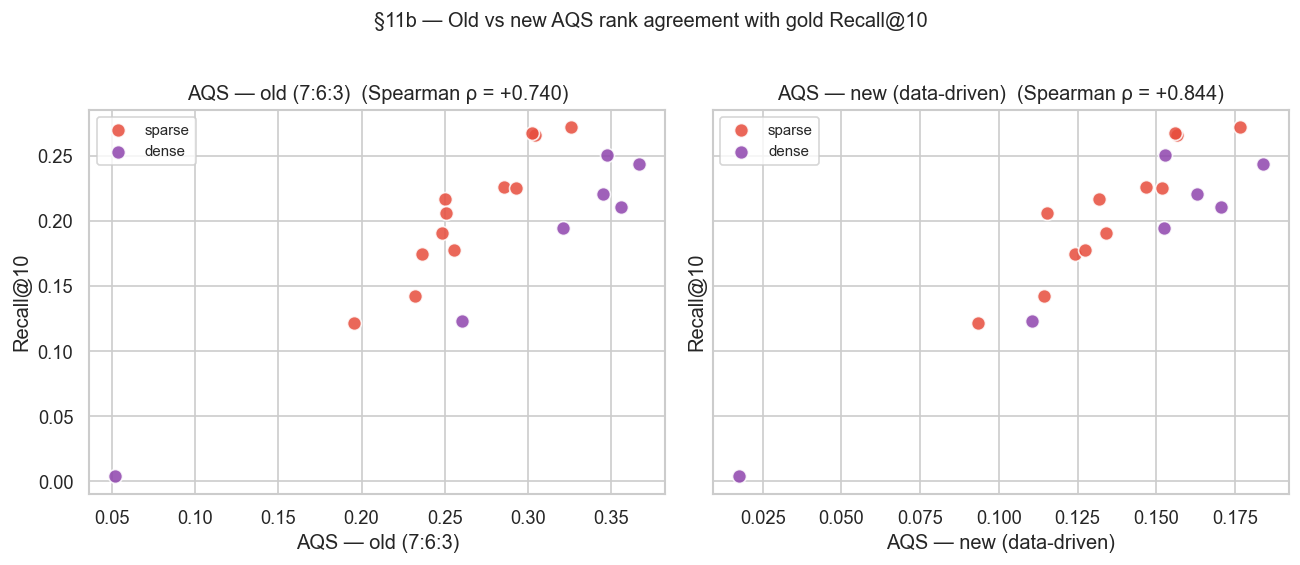

In [26]:
# 11b — side-by-side rank-rank scatters: AQS-old (7:6:3) vs AQS-new (data-driven).
if aqs_payload is not None:
    w_new = aqs_payload["weights_full"]
    aqs_new = (
        w_new["umbrela"]  * summary["T3/umbrela/mean"]
      + w_new["erag"]     * summary["T3/erag/mean"]
      + w_new["ragas_wa"] * summary["T3/ragas_wa/mean"]
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
    panels = [
        ("AQS — old (7:6:3)",         summary["T3/AQS"],   aqs_payload["rho_old_7_6_3"]),
        ("AQS — new (data-driven)",   aqs_new,             aqs_payload["rho_in_sample"]),
    ]
    for ax, (title, x, rho) in zip(axes, panels):
        for fam, color in FAMILY_COLORS.items():
            mask = summary["family"] == fam
            ax.scatter(x[mask], summary.loc[mask, "Recall@10"],
                       color=color, label=fam, s=70, alpha=0.85, edgecolor="white")
        ax.set_xlabel(title); ax.set_ylabel("Recall@10")
        ax.set_title(f"{title}  (Spearman ρ = {rho:+.3f})")
        ax.legend(loc="best", frameon=True, fontsize=9)
    plt.suptitle("§11b — Old vs new AQS rank agreement with gold Recall@10",
                 y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "11b_aqs_old_vs_new.png")
    plt.show()


**Take-away — read this as component-selection, not weight-fitting.** The data-driven optimum collapses near `(0, ~0.85, ~0.15)` — i.e. **AQS = eRAG-mean with a small RAGAS-WA refinement and zero weight on UMBRELA**. Held-out (LOO) Spearman is essentially identical to in-sample, with tight 95% CIs (eRAG ≥ 0.82 in every fold) and 17 of 19 folds returning the *same* (0, 0.85, 0.15) point. The lift over eRAG-mean alone is small (ρ +0.79 → +0.84).

§10 explains *why* eRAG wins, and why that is not coincidence on this 19-system sample: eRAG is the only component whose ceiling sits above its best retriever, i.e. the only one that doesn't systematically prefer surface plausibility to gold. The optimizer dumping weight onto eRAG and nothing onto UMBRELA is the same finding §10 produces in absolute-value language and §10.1 produces in atomic-cell language — three independent angles on the same conclusion.

**Recommendation.** Retire the legacy 7:6:3 AQS — it is *worse* than eRAG-mean alone (ρ +0.74 vs +0.79) and one of the three metrics that rate the best retriever above the oracle. Report **eRAG-mean** as the headline reference-free metric for BSARD-like legal RAG retrieval, with UMBRELA and RAGAS-WA disclosed alongside as surface-plausibility diagnostics. The `T3/AQS_dd` column is exposed in `summary.csv` for any downstream code that still wants a single composite number; it is essentially eRAG with a 15% RAGAS-WA refinement.
